# Function 2: Mystery ML model
Imagine a black box, or a mystery ML model, that takes two numbers as input and returns a log-likelihood score. Your goal is to maximise that score, but each output is noisy, and depending on where you start, you might get stuck in a local optimum. 

To tackle this, you use Bayesian optimisation, which selects the next inputs based on what it has learned so far. It balances exploration with exploitation, making it well suited to noisy outputs and complex functions with many local peaks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [2]:

def load_inputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    # Make the file a proper list of lists
    content = "[" + content.replace("]\n[", "],[") + "]"

    # Safe eval with restricted globals
    return eval(content, {"array": np.array})


def load_outputs(file_path):
    with open(file_path, "r") as f:
        content = f.read()

    content = "[" + content.replace("]\n[", "],[") + "]"

    return eval(content, {"np": np})


def get_input_points(function_number, file_path="../inputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_inputs(file_path)
    index = function_number - 1

    inputs = [dataset[index] for dataset in data]
    return np.array(inputs)


def get_output_points(function_number, file_path="../outputs.txt"):
    if not 1 <= function_number <= 8:
        raise ValueError("Function number must be between 1 and 8")

    data = load_outputs(file_path)
    index = function_number - 1

    outputs = [row[index] for row in data]
    return np.array(outputs)

# Load inputs
X = np.load(r'initial_inputs.npy')
y = np.load(r'initial_outputs.npy')

# Get input and outputs from submissions
inputs_array = get_input_points(2)
outputs_array = get_output_points(2)

# Append inputs_f1_array to X
X = np.vstack((X, inputs_array))

# Append outputs_f1_array to Y
y = np.hstack((y, outputs_array))

print("New shape of X:", X.shape)
print("New shape of Y:", y.shape)

New shape of X: (19, 2)
New shape of Y: (19,)


Using Bayesian Optimisation and considering an Upper Confidence Bound acquisition function. Surrogate Model: A probabilistic model (Gaussian Process) that approximates the objective function.

In [3]:
kernel = Matern(length_scale=0.1, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6)
gp.fit(X, y)

GaussianProcessRegressor(alpha=1e-06, kernel=Matern(length_scale=0.1, nu=2.5))

In [4]:
def ucb_acquisition(x, gp, kappa=2.0):
    mu, sigma = gp.predict(x, return_std=True)
    return mu + kappa * sigma

X_candidates = np.random.rand(10000, 2)
ucb_values = ucb_acquisition(X_candidates, gp, kappa=0.5)
next_point = X_candidates[np.argmax(ucb_values)]

formatted_next_query = f"{next_point[0]:.6f}-{next_point[1]:.6f}"

print("Next Query Point:", formatted_next_query)

Next Query Point: 0.611523-0.599261


To optimize the acquisition function, we will simply use gridsearch over a space of 10,000 grid points

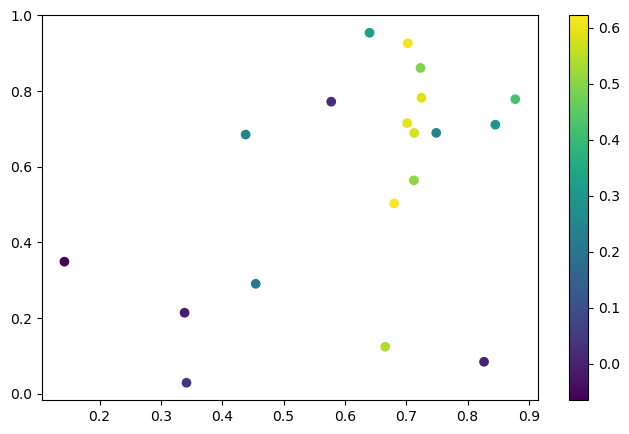

In [5]:
# Define grid of points
# We know the input is in the range 0.000000 to 0.999999
x1 = np.linspace(0.000000, .999999, 100)  # Assuming the search space is within [0, 1] for both dimensions
# We know the input is in the range 0.000000 to 0.999999
x2 = np.linspace(0.000000, .999999, 100)
X_grid = np.array(np.meshgrid(x1, x2)).reshape(2, -1).T

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()